In [1]:
%load_ext autoreload
%autoreload 2
%cd ..

/home/william/ad-hoc projects/different stock data


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import spearmanr, pearsonr

from stock_data.config import (
    EARNINGS_LAG_DAYS, PROD_CFG, XGB_PARAMS, RIDGE_PARAMS, RF_PARAMS,
    ENS_W, INITIAL_CAPITAL, COST_BPS, WEIGHT_THRESHOLD, N_BOOT,
)
from stock_data.dataset import (
    load_sp500_universe, get_active_symbols,
    fetch_quarterly_income, fetch_quarterly_balance_sheets,
    fetch_quarterly_cashflows, fetch_annual_income,
    reshape_statements, drop_sparse_pairs, pivot_statements,
    reshape_annual_income, download_prices, download_macro,
    compute_forward_returns, compute_realized_vol,
)
from stock_data.features import build_features
from stock_data.modeling.predict import (
    winsorize, shrink_to_mean, bootstrap_ci, safe_spearmanr,
)
from stock_data.modeling.train import walk_forward, factor_benchmarks
from stock_data.plots import plot_walk_forward_diagnostics, plot_simulation

In [3]:
# Load S&P 500 universe
smp500_stocks = load_sp500_universe("data/raw/sp500_monthly.csv")
smp500_stocks.info()
smp500_stocks.head()

<class 'pandas.DataFrame'>
Index: 503 entries, 0 to 1000
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   symbol        503 non-null    str           
 1   date_added    503 non-null    datetime64[us]
 2   date_removed  0 non-null      datetime64[us]
dtypes: datetime64[us](2), str(1)
memory usage: 15.7 KB


,symbol,date_added,date_removed
0,A,2008-01-31,NaT
2,AAPL,2008-01-31,NaT
6,ABT,2008-01-31,NaT
10,ADBE,2008-01-31,NaT
11,ADI,2008-01-31,NaT


In [4]:
# Currently active S&P 500 members
current_sp500 = smp500_stocks[smp500_stocks["date_removed"].isna()]
symbols = get_active_symbols(current_sp500)
print(f"Number of currently active S&P 500 symbols: {len(symbols)}")
print(f"First 10 symbols: {symbols[:10]}")

Number of currently active S&P 500 symbols: 503
First 10 symbols: ['A', 'AAPL', 'ABT', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP']


In [5]:
# Fetch quarterly income statements
quarterly_income_stmts, failed_symbols = fetch_quarterly_income(symbols)

# Reshape and clean
combined = reshape_statements(quarterly_income_stmts)
combined = drop_sparse_pairs(combined)
print(f"\nCombined table shape: {combined.shape}")
combined.head(20)

  Quarterly income: 50/503...
  Quarterly income: 100/503...
  Quarterly income: 150/503...
  Quarterly income: 200/503...
  Quarterly income: 250/503...
  Quarterly income: 300/503...
  Quarterly income: 350/503...
  Quarterly income: 400/503...
  Quarterly income: 450/503...
  Quarterly income: 500/503...
  Quarterly income: done in 114.2s — 501 symbols (0 failed)
  Dropped 8017 >50%-NaN (symbol,date) pairs (472,416 → 112,426 rows)

Combined table shape: (112426, 1)


value
symbol date       item                                                            
A      2025-01-31 Basic Average Shares                                2.850000e+08
                  Basic EPS                                           1.120000e+00
                  Cost Of Revenue                                     7.820000e+08
                  Diluted Average Shares                              2.870000e+08
                  Diluted EPS                                         1.110000e+00
                  Diluted NI Availto Com Stockholders                 3.180000e+08
                  EBIT                                                3.950000e+08
                  EBITDA                                              4.670000e+08
                  Gross Profit                                        8.990000e+08
                  Interest Expense                                    2.800000e+07
                  Interest Expense Non Operating                      2.800000e+07
                  Interest Income                                     1.500000e+07
                  Interest Income Non Operating                       1.500000e+07
                  Net Income                                          3.180000e+08
                  Net Income Common Stockholders                      3.180000e+08
                  Net Income Continuous Operations                    3.180000e+08
                  Net Income From Continuing And Discontinued Ope...  3.180000e+08
                  Net Income From Continuing Operation Net Minori...  3.180000e+08
                  Net Income Including Noncontrolling Interests       3.180000e+08
                  Net Interest Income                                -1.300000e+07

In [6]:
# Pivot income statement to wide format
features_raw = pivot_statements(combined)
print(f"Features raw: {features_raw.shape}")
features_raw.head()

Features raw: (2504, 84)


Amortization  Amortization Of Intangibles Income Statement  \
symbol date                                                                     
A      2025-01-31           NaN                                           NaN   
       2025-04-30           NaN                                           NaN   
       2025-07-31           NaN                                           NaN   
       2025-10-31           NaN                                           NaN   
       2026-01-31           NaN                                           NaN   

                   Average Dilution Earnings  Basic Average Shares  Basic EPS  \
symbol date                                                                     
A      2025-01-31                        NaN           285000000.0       1.12   
       2025-04-30                        NaN           285000000.0       0.75   
       2025-07-31                        NaN           284000000.0       1.18   
       2025-10-31                        NaN           283000000.0       1.53   
       2026-01-31                        NaN           283000000.0       1.08   

                   Cost Of Revenue  Depletion Income Statement  \
symbol date                                                      
A      2025-01-31      782000000.0                         NaN   
       2025-04-30      802000000.0                         NaN   
       2025-07-31      850000000.0                         NaN   
       2025-10-31      871000000.0                         NaN   
       2026-01-31      852000000.0                         NaN   

                   Depreciation Amortization Depletion Income Statement  \
symbol date                                                               
A      2025-01-31                                                NaN      
       2025-04-30                                                NaN      
       2025-07-31                                                NaN      
       2025-10-31                                                NaN      
       2026-01-31                                                NaN      

                   Depreciation And Amortization In Income Statement  \
symbol date                                                            
A      2025-01-31                                                NaN   
       2025-04-30                                                NaN   
       2025-07-31                                                NaN   
       2025-10-31                                                NaN   
       2026-01-31                                                NaN   

                   Depreciation Income Statement  ...  \
symbol date                                       ...   
A      2025-01-31                            NaN  ...   
       2025-04-30                            NaN  ...   
       2025-07-31                            NaN  ...   
       2025-10-31                            NaN  ...   
       2026-01-31                            NaN  ...   

                   Tax Effect Of Unusual Items  Tax Provision  \
symbol date                                                     
A      2025-01-31                          0.0     49000000.0   
       2025-04-30                          0.0     45000000.0   
       2025-07-31                          0.0     30000000.0   
       2025-10-31                          0.0      8000000.0   
       2026-01-31                          0.0     59000000.0   

                   Tax Rate For Calcs  Total Expenses  \
symbol date                                             
A      2025-01-31              0.1340    1.305000e+09   
       2025-04-30              0.1730    1.368000e+09   
       2025-07-31              0.0820    1.378000e+09   
       2025-10-31              0.0181    1.418000e+09   
       2026-01-31              0.1620    1.445000e+09   

                   Total Operating Income As Reported  \
symbol date                                             
A      2025-01-31  

In [7]:
# Fetch quarterly balance sheets
quarterly_balance_sheets, _ = fetch_quarterly_balance_sheets(symbols)
bs_raw = pivot_statements(reshape_statements(quarterly_balance_sheets))
print(f"Balance sheet: {bs_raw.shape}")

  Quarterly balance sheet: 50/503...
  Quarterly balance sheet: 100/503...
  Quarterly balance sheet: 150/503...
  Quarterly balance sheet: 200/503...
  Quarterly balance sheet: 250/503...
  Quarterly balance sheet: 300/503...
  Quarterly balance sheet: 350/503...
  Quarterly balance sheet: 400/503...
  Quarterly balance sheet: 450/503...
  Quarterly balance sheet: 500/503...
  Quarterly balance sheet: done in 135.1s — 501 symbols (0 failed)
Balance sheet: (2918, 138)


In [8]:
# Fetch quarterly cash flows
quarterly_cashflows, _ = fetch_quarterly_cashflows(symbols)
cf_raw = pivot_statements(reshape_statements(quarterly_cashflows))
print(f"Cash flow: {cf_raw.shape}")

  Quarterly cash flow: 50/503...
  Quarterly cash flow: 100/503...
  Quarterly cash flow: 150/503...
  Quarterly cash flow: 200/503...
  Quarterly cash flow: 250/503...
  Quarterly cash flow: 300/503...
  Quarterly cash flow: 350/503...
  Quarterly cash flow: 400/503...
  Quarterly cash flow: 450/503...
  Quarterly cash flow: 500/503...
  Quarterly cash flow: done in 122.4s — 501 symbols (0 failed)
Cash flow: (2988, 110)


In [9]:
# Fetch annual income statements (for YoY growth)
annual_income_stmts, _ = fetch_annual_income(symbols)
annual_raw = reshape_annual_income(annual_income_stmts)
print(f"Annual raw: {annual_raw.shape}")

  Annual income: 50/503...
  Annual income: 100/503...
  Annual income: 150/503...
  Annual income: 200/503...
  Annual income: 250/503...
  Annual income: 300/503...
  Annual income: 350/503...
  Annual income: 400/503...
  Annual income: 450/503...
  Annual income: 500/503...
  Annual income: done in 112.0s — 501 symbols (0 failed)
Annual raw: (2386, 84)


In [10]:
# Download daily stock prices
inc_symbols = combined.index.get_level_values("symbol").unique().tolist()
all_inc_dates = combined.index.get_level_values("date")
min_date = all_inc_dates.min() - pd.Timedelta(days=400)
max_date = all_inc_dates.max() + pd.Timedelta(days=120)

close_prices = download_prices(inc_symbols, min_date, max_date)

[*********************100%***********************]  501 of 501 completed


  close_prices: 329,926 rows, 501 symbols


In [11]:
# Download macro indicators
macro_df = download_macro(min_date, max_date)
print(f"Macro features: {macro_df.shape}")
print(f"Columns: {macro_df.columns.tolist()}")
macro_df.tail()

Macro features: (662, 10)
Columns: ['vix', 'treasury_10y', 'treasury_3m', 'yield_curve', 'vix_20d_ma', 'vix_regime', 'vix_change_20d', 'sp500_ret_60d', 'sp500_ret_20d', 'sp500_vol_20d']


,vix,treasury_10y,treasury_3m,yield_curve,vix_20d_ma,vix_regime,vix_change_20d,sp500_ret_60d,sp500_ret_20d,sp500_vol_20d
Date,,,,,,,,,,
2026-04-13,19.120001,4.297,3.603,0.694,24.5915,0.0,-0.296800,-0.005827,0.038306,0.196811
2026-04-14,18.360001,4.256,3.612,0.644,24.3340,0.0,-0.219056,0.003299,0.040004,0.197807
2026-04-15,18.170000,4.282,3.612,0.670,24.1240,0.0,-0.187751,0.011951,0.045690,0.198929
2026-04-16,17.940001,4.309,3.610,0.699,23.7665,0.0,-0.284974,0.035961,0.062883,0.189838
2026-04-17,18.230000,NaN,NaN,NaN,23.4750,0.0,-0.242311,NaN,NaN,NaN


In [12]:
# Compute forward returns with realistic earnings lag
sym_date_pairs = combined.index.droplevel("item").unique()
returns_df = compute_forward_returns(close_prices, sym_date_pairs)
returns_df["return_quantile"] = returns_df.groupby("date")["next_q_return"].rank(pct=True)

print(f"Computed {len(returns_df)} returns with {EARNINGS_LAG_DAYS}-day earnings lag")
print(f"Unique symbols: {returns_df['symbol'].nunique()}")
returns_df.head(10)

Computed 2002 returns with 45-day earnings lag
Unique symbols: 501


,symbol,date,buy_date,sell_date,next_q_return,return_quantile
0,A,2025-01-31,2025-03-12,2025-06-12,-0.005735,0.300000
1,A,2025-04-30,2025-06-09,2025-09-09,0.083741,0.625000
2,A,2025-07-31,2025-09-09,2025-12-09,0.116217,0.650000
3,A,2025-10-31,2025-12-10,2026-03-10,-0.194004,0.125000
4,AAPL,2024-12-31,2025-02-10,2025-05-09,-0.127915,0.232346
5,AAPL,2025-03-31,2025-05-12,2025-08-11,0.078978,0.650794
6,AAPL,2025-06-30,2025-08-11,2025-11-10,0.187126,0.836735
7,AAPL,2025-09-30,2025-11-10,2026-02-09,0.020217,0.351474
8,ABBV,2024-12-31,2025-02-10,2025-05-09,-0.021194,0.564920
9,ABBV,2025-03-31,2025-05-12,2025-08-11,0.054115,0.566893


In [13]:
# Compute realized forward volatility
vol_df = compute_realized_vol(returns_df, close_prices)
returns_full = returns_df.merge(vol_df, on=["symbol", "date"], how="inner")
print(f"Returns + vol dataset: {len(returns_full)} rows")
returns_full.head()

Returns + vol dataset: 2002 rows


,symbol,date,buy_date,sell_date,next_q_return,return_quantile,realized_vol,realized_downside_vol,realized_max_dd,realized_var5,realized_skew,realized_kurtosis
0,A,2025-01-31,2025-03-12,2025-06-12,-0.005735,0.300000,0.407780,0.278346,-0.191706,-0.041324,0.232587,2.278090
1,A,2025-04-30,2025-06-09,2025-09-09,0.083741,0.625000,0.296480,0.181127,-0.097689,-0.024195,0.045283,1.331442
2,A,2025-07-31,2025-09-09,2025-12-09,0.116217,0.650000,0.289601,0.137206,-0.105343,-0.022058,1.276086,4.246281
3,A,2025-10-31,2025-12-10,2026-03-10,-0.194004,0.125000,0.258038,0.169446,-0.225222,-0.027424,0.165538,-0.108448
4,AAPL,2024-12-31,2025-02-10,2025-05-09,-0.127915,0.232346,0.507253,0.362411,-0.302226,-0.048175,1.205572,8.984468


In [14]:
# Build full feature matrix + targets
risk_model_df, feature_cols_all = build_features(
    features_raw, bs_raw, cf_raw, annual_raw,
    close_prices, macro_df, returns_df, returns_full,
)
print(f"Modeling rows: {risk_model_df.shape[0]}")
risk_model_df.head()

  Features: 172 | Rows: 2002
Modeling rows: 2002


gross_margin  operating_margin  net_margin  ebitda_margin  \
symbol date                                                                    
A      2025-01-31      0.534801          0.234979    0.189173       0.277811   
       2025-04-30      0.519185          0.173261    0.128897       0.217026   
       2025-07-31      0.510932          0.226697    0.193326       0.268124   
       2025-10-31      0.531972          0.252015    0.233208       0.290167   
AAPL   2024-12-31      0.468825          0.344586    0.292277       0.369364   

                   tax_rate  interest_coverage  rd_intensity  sga_intensity  \
symbol date                                                                   
A      2025-01-31  0.133515          14.107143      0.067222       0.243902   
       2025-04-30  0.173077           9.965517      0.067146       0.272182   
       2025-07-31  0.081967          14.071429      0.063867       0.239931   
       2025-10-31  0.018100          17.370370      0.063944       0.229984   
AAPL   2024-12-31  0.146863                NaN      0.066516       0.057723   

                   cost_efficiency  log_revenue  ...  hist_vol_of_vol_rank  \
symbol date                                      ...                         
A      2025-01-31         0.465199    21.242655  ...              0.200000   
       2025-04-30         0.480815    21.234891  ...              0.350000   
       2025-07-31         0.489068    21.276001  ...              0.225000   
       2025-10-31         0.468028    21.344380  ...              0.425000   
AAPL   2024-12-31         0.531175    25.545964  ...              0.490868   

                   vol_trend_rank  avg_abs_return_rank  next_q_return  \
symbol date                                                             
A      2025-01-31        0.525000             0.400000      -0.005735   
       2025-04-30        0.325000             0.450000       0.083741   
       2025-07-31        0.425000             0.600000       0.116217   
       2025-10-31        0.275000             0.525000      -0.194004   
AAPL   2024-12-31        0.913242             0.385845      -0.127915   

                   return_quantile  realized_vol  realized_downside_vol  \
symbol date                                                               
A      2025-01-31         0.300000      0.407780               0.278346   
       2025-04-30         0.625000      0.296480               0.181127   
       2025-07-31         0.650000      0.289601               0.137206   
       2025-10-31         0.125000      0.258038               0.169446   
AAPL   2024-12-31         0.232346      0.507253               0.362411   

                   realized_max_dd  vol_quantile  risk_adj_return  
symbol date                                                        
A      2025-01-31        -0.191706       0.42500        -0.014065  
       2025-04-30        -0.097689       0.60000         0.282450  
       2025-07-31        -0.105343       0.50000         0.401301  
       2025-10-31        -0.225222       0.22500        -0.751840  
AAPL   2024-12-31        -0.302226       0.77221        -0.252173  

[5 rows x 179 columns]

In [15]:
# (Vol and risk features are already incorporated via build_features)
# Print target distributions
print("Target distributions:")
for t in ["next_q_return", "realized_vol", "risk_adj_return"]:
    print(f"  {t}: mean={risk_model_df[t].mean():.4f}, std={risk_model_df[t].std():.4f}")
print(f"\nCorrelation matrix of targets:")
print(risk_model_df[["next_q_return", "realized_vol", "risk_adj_return"]].corr().round(3))

Target distributions:
  next_q_return: mean=0.0409, std=0.2162
  realized_vol: mean=0.3281, std=0.1531
  risk_adj_return: mean=0.1401, std=0.4998

Correlation matrix of targets:
                 next_q_return  realized_vol  risk_adj_return
next_q_return            1.000         0.087            0.856
realized_vol             0.087         1.000           -0.066
risk_adj_return          0.856        -0.066            1.000


In [16]:
# (Risk features already built via build_features — nothing extra needed here)
print(f"Total feature columns: {len(feature_cols_all)}")
print(f"Sample features: {feature_cols_all[:20]}")

Total feature columns: 172
Sample features: ['gross_margin', 'operating_margin', 'net_margin', 'ebitda_margin', 'tax_rate', 'interest_coverage', 'rd_intensity', 'sga_intensity', 'cost_efficiency', 'log_revenue', 'log_net_income', 'log_ebitda', 'diluted_eps', 'roe', 'roa', 'roic', 'debt_to_equity', 'debt_to_assets', 'leverage_ratio', 'current_ratio']


In [17]:
# (Combined dataset already built — skip to walk-forward)
print(f"Combined dataset: {risk_model_df.shape}")
print(f"Total features: {len(feature_cols_all)}")
print(f"Rows: {len(risk_model_df)}")

Combined dataset: (2002, 179)
Total features: 172
Rows: 2002


In [18]:
# === PRODUCTION WALK-FORWARD ENGINE ===

prod_df, prod_fi, prod_weights_history = walk_forward(
    risk_model_df, feature_cols_all, close_prices,
)

# ── Summary ──
print(f"\n{'='*80}")
print(f"PRODUCTION RESULTS ({len(prod_df)} quarters)")
print(f"{'='*80}")

ex_g = prod_df["gross_ret"] - prod_df["mkt_ret"]
ex_n = prod_df["net_ret"] - prod_df["mkt_ret"]

metrics = [
    ("Avg return (gross)",      f"{prod_df['gross_ret'].mean():+.2%}"),
    ("Avg return (net)",        f"{prod_df['net_ret'].mean():+.2%}"),
    ("Avg market return",       f"{prod_df['mkt_ret'].mean():+.2%}"),
    ("Avg excess (gross)",      f"{ex_g.mean():+.2%}"),
    ("Avg excess (net)",        f"{ex_n.mean():+.2%}"),
    ("Win rate (net > mkt)",    f"{(ex_n > 0).sum()}/{len(prod_df)} ({(ex_n > 0).mean():.0%})"),
    ("Avg holdings",            f"{prod_df['n_held'].mean():.0f}"),
    ("Avg max weight",          f"{prod_df['max_wt'].mean():.2%}"),
    ("Avg turnover (one-way)",  f"{prod_df['turnover'].mean():.0%}"),
    ("Avg tx cost",             f"{prod_df['tx_cost'].mean():.2%}"),
    ("Ledoit-Wolf used",        f"{prod_df['used_lw'].sum()}/{len(prod_df)}"),
]
for label, val in metrics:
    print(f"  {label:30s} {val:>10s}")

print(f"\n  Model quality (avg rank correlation):")
print(f"    Vol model:       {prod_df['vol_rc'].mean():.3f}")
print(f"    Ret ensemble:    {prod_df['ret_rc'].mean():.3f}")
print(f"    Ret XGBoost:     {prod_df['ret_rc_xgb'].mean():.3f}")
print(f"    Ret Ridge:       {prod_df['ret_rc_ridge'].mean():.3f}")
print(f"    Ret RF:          {prod_df['ret_rc_rf'].mean():.3f}")

# ── Feature importance stability ──
print(f"\n{'='*80}")
print("FEATURE IMPORTANCE STABILITY (top 15 by average)")
print(f"{'='*80}\n")

fi_wide = pd.DataFrame({r["date"].date(): r["fi"] for r in prod_fi})
top15 = fi_wide.mean(axis=1).sort_values(ascending=False).head(15)
print(f"  {'Feature':38s} {'Mean':>7s} {'Std':>7s} {'SNR':>7s}")
print(f"  {'-'*62}")
for f in top15.index:
    m, s = fi_wide.loc[f].mean(), fi_wide.loc[f].std()
    print(f"  {f:38s} {m:.4f}  {s:.4f}  {m / (s + 1e-10):.2f}")

WALK-FORWARD ENGINE
  2025-03-31 | 6Q |  51h | G=+2.89% N=+2.69% M=+4.98% Ex=-2.29% | TO=100% | LW | rc=0.09
  2025-06-30 | 9Q |  54h | G=+15.47% N=+15.30% M=+6.65% Ex=+8.65% | TO=83% | LW | rc=0.15
  2025-09-30 | 12Q |  52h | G=+13.46% N=+13.33% M=+8.89% Ex=+4.44% | TO=69% | LW | rc=0.15

PRODUCTION RESULTS (3 quarters)
  Avg return (gross)                +10.61%
  Avg return (net)                  +10.44%
  Avg market return                  +6.84%
  Avg excess (gross)                 +3.76%
  Avg excess (net)                   +3.60%
  Win rate (net > mkt)            2/3 (67%)
  Avg holdings                           52
  Avg max weight                      2.00%
  Avg turnover (one-way)                84%
  Avg tx cost                         0.17%
  Ledoit-Wolf used                      3/3

  Model quality (avg rank correlation):
    Vol model:       0.776
    Ret ensemble:    0.129
    Ret XGBoost:     0.163
    Ret Ridge:       0.058
    Ret RF:          0.137

FEATURE IMPORTAN

FACTOR BENCHMARK COMPARISON

  Strategy                  Avg Q Ret   Excess   Win%  N Q
  -------------------------------------------------------
  Production MV (net)        +10.44%  +3.60%   67%   3
  Market (equal wt)           +6.84%      ---    ---   3
  Low Vol                     +2.42%  -4.42%    0%   3
  Momentum (3m)               +9.51%  +2.67%   67%   3
  Quality (ROE)               +7.30%  +0.46%   67%   3

BOOTSTRAP CONFIDENCE INTERVALS (10,000 resamples)

  Production MV (net of costs):
    Point estimate:   +3.60%
    95% CI:           [-2.29%, +8.65%]
    P(excess <= 0):   0.153
    N quarters:       3

  Low Vol:
    Excess: -4.42%  CI: [-7.07%, -2.65%]  P(<=0): 1.000

  Momentum (3m):
    Excess: +2.67%  CI: [-3.10%, +6.74%]  P(<=0): 0.151

  Quality (ROE):
    Excess: +0.46%  CI: [-1.29%, +1.63%]  P(<=0): 0.259


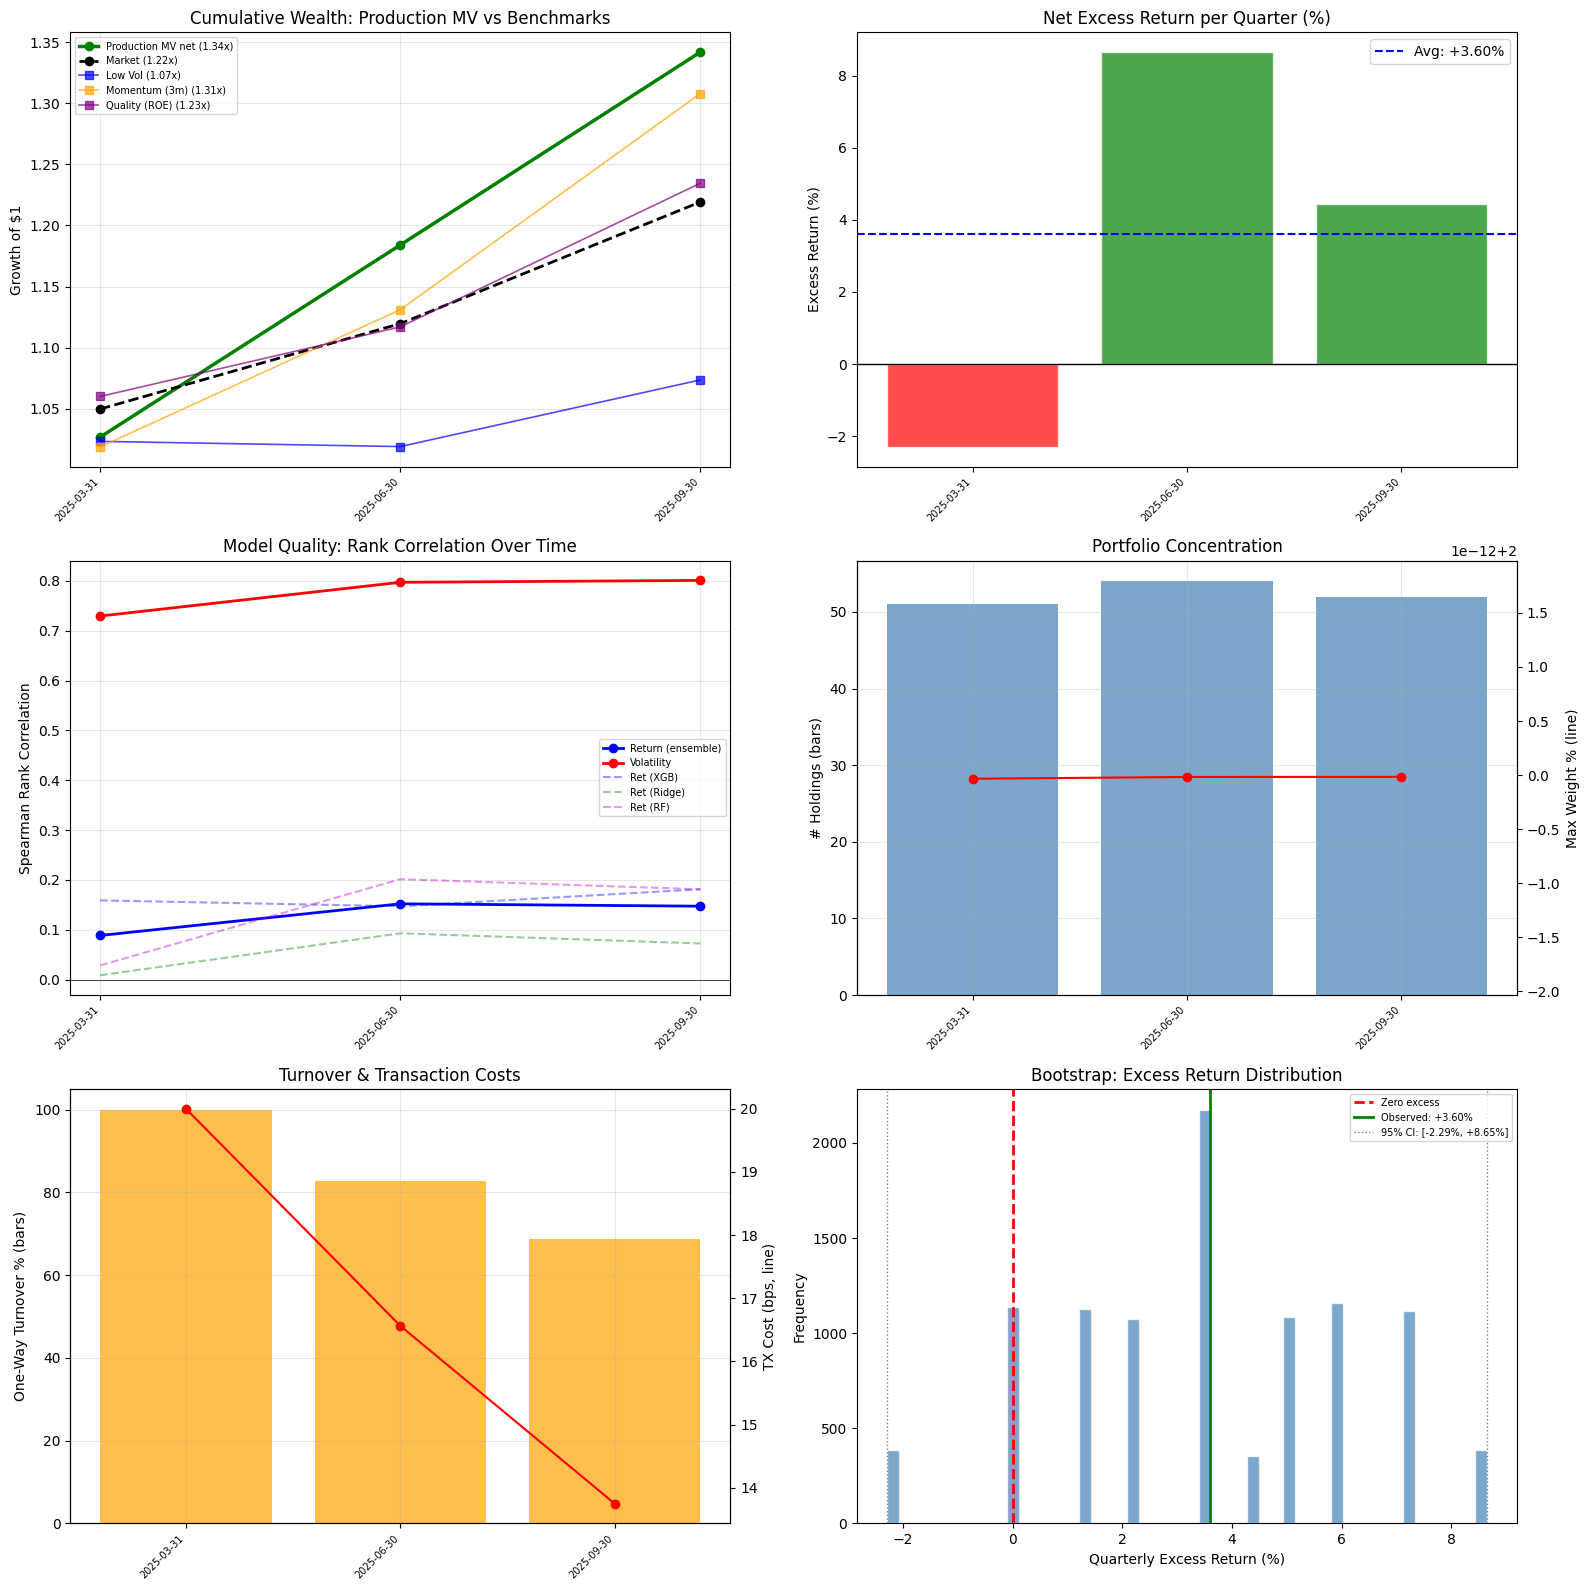


FINAL PRODUCTION ASSESSMENT

  Annualized excess:     +15.2%
  Annualized Sharpe:     1.30
  Win rate vs market:    2/3 (67%)
  Max drawdown:          +0.00%
  t-statistic:           1.13
  p-value:               0.376
  Bootstrap 95% CI:      [-2.29%, +8.65%]
  Bootstrap P(<=0):      0.153



In [19]:
# === FACTOR BENCHMARKS + BOOTSTRAP + DIAGNOSTICS ===

factor_results = factor_benchmarks(risk_model_df, feature_cols_all, prod_df)

print("=" * 80)
print("FACTOR BENCHMARK COMPARISON")
print("=" * 80)
print(f"\n  {'Strategy':25s} {'Avg Q Ret':>9s} {'Excess':>8s} {'Win%':>6s} {'N Q':>4s}")
print(f"  {'-'*55}")

ex_n = prod_df["net_ret"] - prod_df["mkt_ret"]
print(f"  {'Production MV (net)':25s} {prod_df['net_ret'].mean():+8.2%} "
      f"{ex_n.mean():+7.2%} {(ex_n > 0).mean():5.0%} {len(prod_df):3d}")
print(f"  {'Market (equal wt)':25s} {prod_df['mkt_ret'].mean():+8.2%} "
      f"{'---':>8s} {'---':>6s} {len(prod_df):3d}")

factor_excess_for_boot = {}
for fname, results in factor_results.items():
    if not results:
        continue
    fdf = pd.DataFrame(results)
    fdf_match = fdf[fdf["test_date"].isin(prod_df["test_date"].values)].sort_values("test_date")
    if len(fdf_match) < 2:
        continue
    avg_ret = fdf_match["port_ret"].mean()
    avg_ex = fdf_match["excess"].mean()
    win = (fdf_match["excess"] > 0).mean()
    print(f"  {fname:25s} {avg_ret:+8.2%} {avg_ex:+7.2%} {win:5.0%} {len(fdf_match):3d}")
    factor_excess_for_boot[fname] = fdf_match["excess"].values

# ── Bootstrap confidence intervals ──
print(f"\n{'='*80}")
print(f"BOOTSTRAP CONFIDENCE INTERVALS ({N_BOOT:,} resamples)")
print(f"{'='*80}")

ex_net_vals = ex_n.values
ci_lo, ci_hi, boot_p, boot_means = bootstrap_ci(ex_net_vals, N_BOOT)

print(f"\n  Production MV (net of costs):")
print(f"    Point estimate:   {ex_net_vals.mean():+.2%}")
print(f"    95% CI:           [{ci_lo:+.2%}, {ci_hi:+.2%}]")
print(f"    P(excess <= 0):   {boot_p:.3f}")
print(f"    N quarters:       {len(ex_net_vals)}")

for fname, fex in factor_excess_for_boot.items():
    if len(fex) < 3:
        continue
    flo, fhi, fp, _ = bootstrap_ci(fex, N_BOOT)
    print(f"\n  {fname}:")
    print(f"    Excess: {fex.mean():+.2%}  CI: [{flo:+.2%}, {fhi:+.2%}]  P(<=0): {fp:.3f}")

# ── Diagnostic plots ──
fig = plot_walk_forward_diagnostics(prod_df, factor_results, boot_means, ci_lo, ci_hi, ex_n)
plt.show()

# ── Final honest assessment ──
ann_excess_net = (1 + ex_n.mean())**4 - 1
net_sharpe = (ex_n.mean() / ex_n.std() * 2) if ex_n.std() > 0 else 0
wealth_net = (1 + prod_df["net_ret"]).cumprod()
max_dd = ((wealth_net / wealth_net.cummax()) - 1).min()

if len(ex_n) >= 3:
    t_stat, p_val = stats.ttest_1samp(ex_n, 0)
else:
    t_stat, p_val = 0, 1.0

print(f"\n{'='*80}")
print("FINAL PRODUCTION ASSESSMENT")
print(f"{'='*80}")
print(f"""
  Annualized excess:     {ann_excess_net:+.1%}
  Annualized Sharpe:     {net_sharpe:.2f}
  Win rate vs market:    {(ex_n > 0).sum()}/{len(prod_df)} ({(ex_n > 0).mean():.0%})
  Max drawdown:          {max_dd:+.2%}
  t-statistic:           {t_stat:.2f}
  p-value:               {p_val:.3f}
  Bootstrap 95% CI:      [{ci_lo:+.2%}, {ci_hi:+.2%}]
  Bootstrap P(<=0):      {boot_p:.3f}
""")

In [20]:
# === EXTERNAL VALIDITY ASSESSMENT ===

print("=" * 80)
print("EXTERNAL VALIDITY ASSESSMENT")
print("=" * 80)

# ── 1. Regime dependence ──
print("\n1. REGIME DEPENDENCE")
print("-" * 60)

if len(prod_df) >= 2:
    prod_df["mkt_regime"] = np.where(prod_df["mkt_ret"] >= 0, "Bull", "Bear")
    prod_df["excess_net"] = prod_df["net_ret"] - prod_df["mkt_ret"]

    for regime in ["Bull", "Bear"]:
        subset = prod_df[prod_df["mkt_regime"] == regime]
        if len(subset) > 0:
            print(f"\n  {regime} quarters ({len(subset)}):")
            print(f"    Avg excess: {subset['excess_net'].mean():+.2%}")
            print(f"    Win rate:   {(subset['excess_net'] > 0).mean():.0%}")

    if len(prod_df) >= 3:
        corr, pval = pearsonr(prod_df["mkt_ret"], prod_df["excess_net"])
        print(f"\n  Market-excess correlation: {corr:.3f} (p={pval:.3f})")

# ── 2. Prediction quality ──
print(f"\n2. PREDICTION QUALITY ANALYSIS")
print("-" * 60)
for _, row in prod_df.iterrows():
    d = row["test_date"].date()
    print(f"    {d}: vol_rc={row['vol_rc']:.3f}  ret_rc={row['ret_rc']:.3f}  "
          f"ret_xgb={row['ret_rc_xgb']:.3f}")

# ── 3. Concentration risk ──
X_p = risk_model_df[feature_cols_all].copy()
dp = X_p.index.get_level_values("date")

print(f"\n3. CONCENTRATION RISK")
print("-" * 60)
for td, wdata in prod_weights_history.items():
    w = wdata["weights"]
    n_held = (w > 0.001).sum()
    top5_wt = np.sort(w)[-5:].sum()
    eff_n = 1.0 / np.sum(w ** 2) if np.sum(w ** 2) > 0 else 0
    print(f"  {td.date()}: {n_held} holdings, top-5={top5_wt:.1%}, eff_N={eff_n:.0f}")

# ── 4. Feature importance stability ──
print(f"\n4. FEATURE IMPORTANCE STABILITY")
print("-" * 60)
if len(prod_fi) >= 2:
    fi_df = pd.DataFrame({r["date"].date(): r["fi"] for r in prod_fi})
    fi_ranks = fi_df.rank(ascending=False)
    top10 = fi_df.mean(axis=1).sort_values(ascending=False).head(10).index
    print(f"\n  {'Feature':38s} {'Avg Rank':>8s} {'Rank Std':>8s}")
    for feat_name in top10:
        ranks = fi_ranks.loc[feat_name]
        print(f"  {feat_name:38s} {ranks.mean():7.1f} {ranks.std():8.1f}")

    if fi_df.shape[1] >= 2:
        cols = fi_df.columns.tolist()
        qq_corrs = []
        for i in range(len(cols)):
            for j in range(i + 1, len(cols)):
                c, _ = spearmanr(fi_df[cols[i]], fi_df[cols[j]])
                qq_corrs.append(c)
        print(f"\n  Feature importance rank corr across quarters: "
              f"{np.mean(qq_corrs):.3f} (avg)")

# ── 5. Return attribution ──
print(f"\n5. RETURN ATTRIBUTION")
print("-" * 60)
for td, wdata in prod_weights_history.items():
    w, syms = wdata["weights"], wdata["symbols"]
    te_m = dp == td
    Xte_attr = X_p[te_m]
    act_ret_attr = risk_model_df.loc[Xte_attr.index, "next_q_return"].values
    sym_idx = {s: i for i, s in enumerate(Xte_attr.index.get_level_values("symbol"))}
    mkt_r = act_ret_attr.mean()
    contrib = []
    for i, s in enumerate(syms):
        if s in sym_idx:
            idx = sym_idx[s]
            stock_ex = act_ret_attr[idx] - mkt_r
            contrib.append((s, w[i], act_ret_attr[idx], stock_ex, w[i] * stock_ex))
    contrib.sort(key=lambda x: -abs(x[4]))
    port_excess = sum(c[4] for c in contrib)
    print(f"\n  {td.date()} — Portfolio excess: {port_excess:+.2%}")
    for s, wt, ret_s, ex, c in contrib[:5]:
        print(f"    {s:>8s} {wt:6.1%} {ret_s:+6.2%} {ex:+6.2%} {c:+7.3%}")

EXTERNAL VALIDITY ASSESSMENT

1. REGIME DEPENDENCE
------------------------------------------------------------

  Bull quarters (3):
    Avg excess: +3.60%
    Win rate:   67%

  Market-excess correlation: 0.541 (p=0.636)

2. PREDICTION QUALITY ANALYSIS
------------------------------------------------------------
    2025-03-31: vol_rc=0.729  ret_rc=0.089  ret_xgb=0.159
    2025-06-30: vol_rc=0.797  ret_rc=0.152  ret_xgb=0.147
    2025-09-30: vol_rc=0.801  ret_rc=0.147  ret_xgb=0.181

3. CONCENTRATION RISK
------------------------------------------------------------
  2025-03-31: 51 holdings, top-5=10.0%, eff_N=51
  2025-06-30: 54 holdings, top-5=10.0%, eff_N=52
  2025-09-30: 52 holdings, top-5=10.0%, eff_N=51

4. FEATURE IMPORTANCE STABILITY
------------------------------------------------------------

  Feature                                Avg Rank Rank Std
  treasury_3m                                7.7      9.9
  treasury_10y                               3.7      2.5
  vix_20d

PRACTICE SIMULATION: $1,000,000 PORTFOLIO
  Q 2025-03-31: $     998,000 → $   1,053,297 (+5.54%) | 51 stocks
  Q 2025-06-30: $   1,051,551 → $   1,182,458 (+12.45%) | 54 stocks
  Q 2025-09-30: $   1,180,832 → $   1,366,879 (+15.76%) | 52 stocks


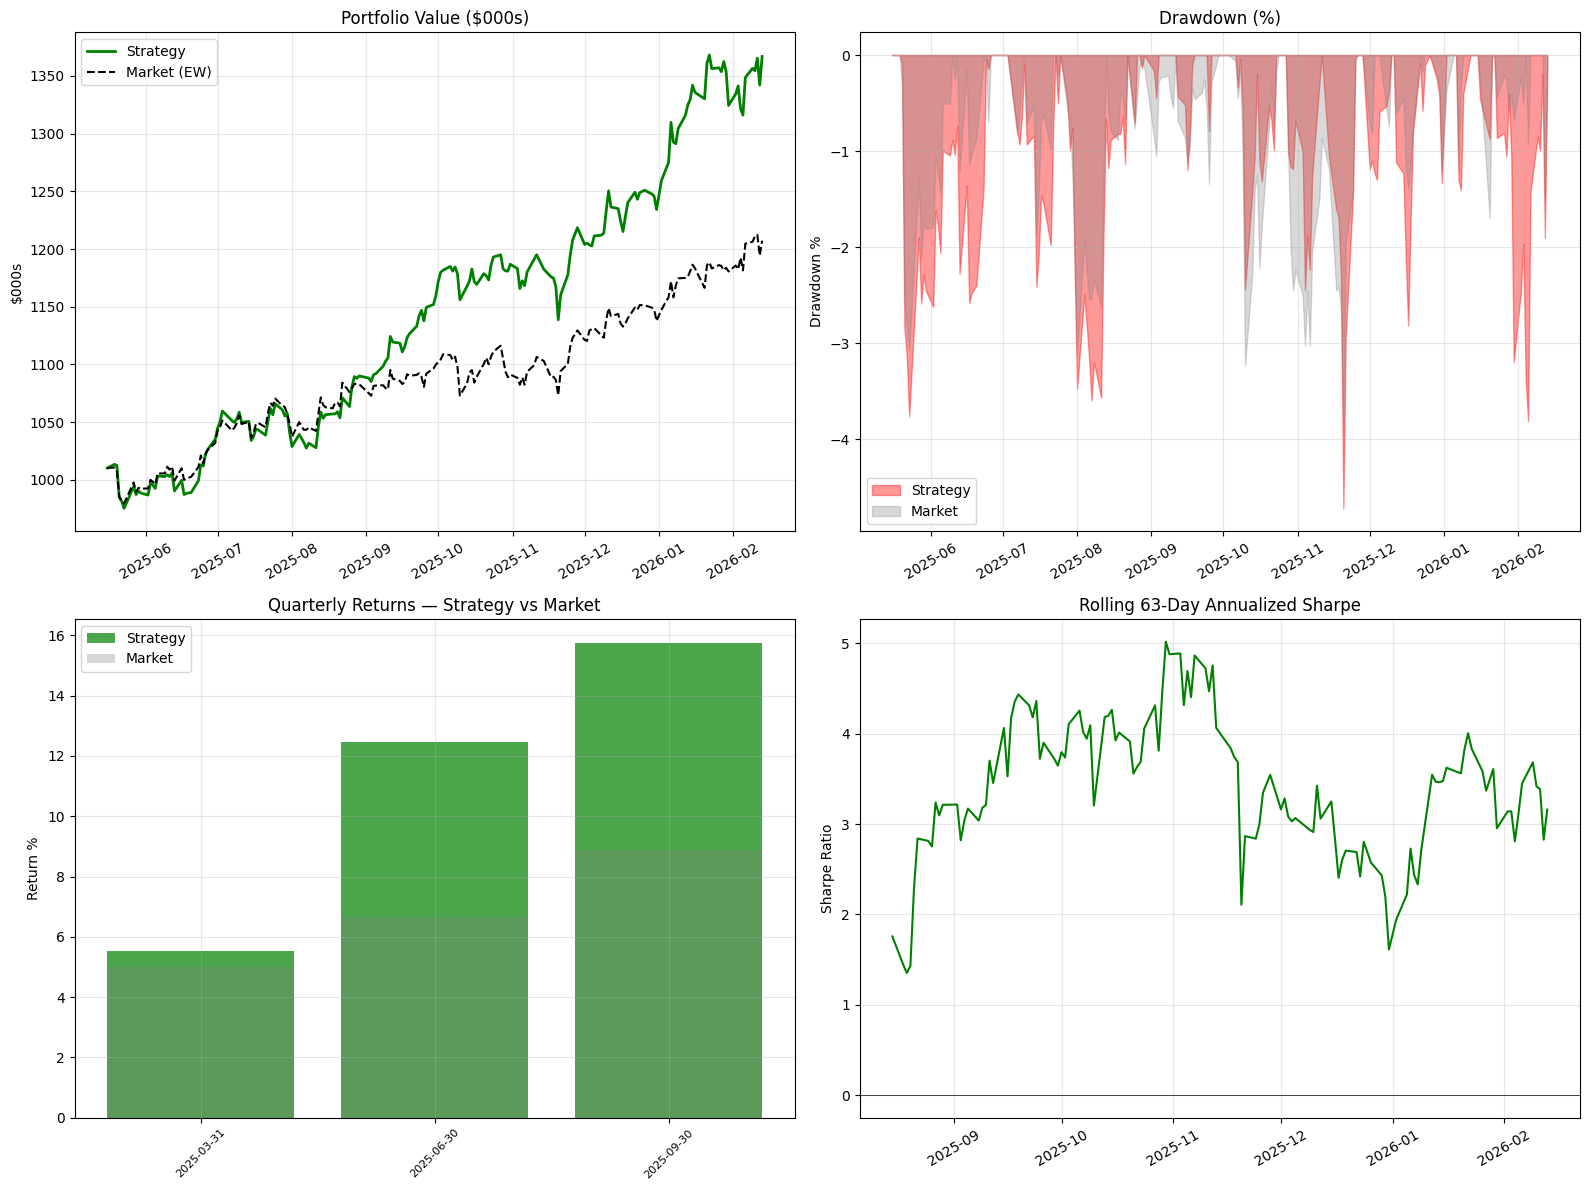


SIMULATION RESULTS
  Final value:  $  1,366,879 (strategy)  $  1,207,264 (market)
  Ann return:        52.72% (strategy)       29.07% (market)
  Ann vol:           14.41%
  Sharpe:       3.66


In [21]:
# === PRACTICE SIMULATION: REALISTIC PORTFOLIO MANAGEMENT ===

print("=" * 80)
print(f"PRACTICE SIMULATION: ${INITIAL_CAPITAL:,.0f} PORTFOLIO")
print("=" * 80)

daily_records = []
portfolio_value = INITIAL_CAPITAL
prev_weights_map = {}
quarter_log = []

for _, row in prod_df.iterrows():
    td = row["test_date"]
    if td not in prod_weights_history:
        continue
    wdata = prod_weights_history[td]
    raw_w, raw_s = wdata["weights"], wdata["symbols"]
    mask = raw_w > WEIGHT_THRESHOLD
    s = [sym for sym, m in zip(raw_s, mask) if m]
    w = raw_w[mask]
    w = w / w.sum()

    buy_dt = td + pd.Timedelta(days=EARNINGS_LAG_DAYS)
    sell_dt = td + pd.DateOffset(months=3) + pd.Timedelta(days=EARNINGS_LAG_DAYS)

    held_prices = close_prices[
        (close_prices["symbol"].isin(s)) &
        (close_prices["date"] >= buy_dt) &
        (close_prices["date"] <= sell_dt)
    ].pivot(index="date", columns="symbol", values="close").sort_index()
    if len(held_prices) < 5:
        continue
    avail = [sym for sym in s if sym in held_prices.columns]
    if len(avail) < 10:
        continue

    w_map = dict(zip(s, w))
    weights_vec = np.array([w_map.get(sym, 0) for sym in avail])
    weights_vec = weights_vec / weights_vec.sum()
    daily_ret = held_prices[avail].pct_change().dropna()
    if len(daily_ret) < 3:
        continue

    turnover = sum(abs(w_map.get(sym, 0) - prev_weights_map.get(sym, 0))
                   for sym in set(avail) | set(prev_weights_map.keys())) / 2
    if not prev_weights_map:
        turnover = 1.0
    tx_cost = turnover * COST_BPS / 10000
    portfolio_value *= (1 - tx_cost)
    start_val = portfolio_value
    current_weights = weights_vec.copy()

    for day_idx in range(len(daily_ret)):
        day_return = (current_weights * daily_ret.iloc[day_idx][avail].values).sum()
        portfolio_value *= (1 + day_return)
        stock_vals = current_weights * (1 + daily_ret.iloc[day_idx][avail].values)
        current_weights = stock_vals / stock_vals.sum()
        daily_records.append({
            "date": daily_ret.index[day_idx], "quarter": td,
            "portfolio_value": portfolio_value, "daily_return": day_return,
        })

    quarter_ret = portfolio_value / start_val - 1
    quarter_log.append({
        "quarter": td, "start_value": start_val, "end_value": portfolio_value,
        "sim_return": quarter_ret, "prod_net_return": row["net_ret"],
        "market_return": row["mkt_ret"], "turnover": turnover,
        "tx_cost": tx_cost, "n_stocks": len(avail), "n_days": len(daily_ret),
    })
    prev_weights_map = dict(zip(avail, weights_vec))
    print(f"  Q {td.date()}: ${start_val:>12,.0f} → ${portfolio_value:>12,.0f} "
          f"({quarter_ret:+.2%}) | {len(avail)} stocks")

# ── Market benchmark ──
mkt_value = INITIAL_CAPITAL
mkt_daily = []
for _, row in prod_df.iterrows():
    td = row["test_date"]
    buy_dt = td + pd.Timedelta(days=EARNINGS_LAG_DAYS)
    sell_dt = td + pd.DateOffset(months=3) + pd.Timedelta(days=EARNINGS_LAG_DAYS)
    all_syms = risk_model_df.loc[
        risk_model_df.index.get_level_values("date") == td
    ].index.get_level_values("symbol").tolist()
    mkt_px = close_prices[
        (close_prices["symbol"].isin(all_syms)) &
        (close_prices["date"] >= buy_dt) & (close_prices["date"] <= sell_dt)
    ].pivot(index="date", columns="symbol", values="close").sort_index()
    if len(mkt_px) < 5:
        continue
    mkt_ret = mkt_px.pct_change().dropna().mean(axis=1)
    for day_idx in range(len(mkt_ret)):
        mkt_value *= (1 + mkt_ret.iloc[day_idx])
        mkt_daily.append({"date": mkt_ret.index[day_idx], "market_value": mkt_value})

sim_df = pd.DataFrame(daily_records).set_index("date").sort_index()
mkt_sim = pd.DataFrame(mkt_daily).set_index("date").sort_index()
qlog = pd.DataFrame(quarter_log)

if len(sim_df) > 0 and len(mkt_sim) > 0:
    fig = plot_simulation(sim_df, mkt_sim, qlog, INITIAL_CAPITAL)
    plt.show()

    combined_sim = sim_df[["portfolio_value"]].join(mkt_sim[["market_value"]], how="inner")
    final_port = combined_sim["portfolio_value"].iloc[-1]
    final_mkt = combined_sim["market_value"].iloc[-1]
    n_days = len(combined_sim)
    n_years = n_days / 252
    port_daily_ret = combined_sim["portfolio_value"].pct_change().dropna()
    port_ann_ret = (final_port / INITIAL_CAPITAL) ** (1 / max(n_years, 0.1)) - 1
    mkt_ann_ret = (final_mkt / INITIAL_CAPITAL) ** (1 / max(n_years, 0.1)) - 1
    port_ann_vol = port_daily_ret.std() * np.sqrt(252)

    print(f"\n{'='*80}")
    print(f"SIMULATION RESULTS")
    print(f"{'='*80}")
    print(f"  Final value:  ${final_port:>11,.0f} (strategy)  ${final_mkt:>11,.0f} (market)")
    print(f"  Ann return:   {port_ann_ret:>11.2%} (strategy)  {mkt_ann_ret:>11.2%} (market)")
    print(f"  Ann vol:      {port_ann_vol:>11.2%}")
    print(f"  Sharpe:       {port_ann_ret / port_ann_vol:.2f}" if port_ann_vol > 0 else "")

In [22]:
# === ITERATION: STABLE-FEATURE MODEL + FACTOR-NEUTRAL ATTRIBUTION ===

import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor as RFR

X_p = risk_model_df[feature_cols_all].copy()
y_ret_p = risk_model_df["next_q_return"].copy()
y_vol_p = risk_model_df["realized_vol"].copy()
ok_mask = y_ret_p.notna() & y_vol_p.notna()
X_p, y_ret_p, y_vol_p = X_p[ok_mask], y_ret_p[ok_mask], y_vol_p[ok_mask]
dp = X_p.index.get_level_values("date")
udp = sorted(dp.unique())

print("=" * 80)
print("ITERATION ON EXTERNAL VALIDITY FINDINGS")
print("=" * 80)

# ── A. Stable-feature model ──
print("\nA. STABLE-FEATURE MODEL")
print("-" * 60)

if len(prod_fi) >= 2:
    fi_df = pd.DataFrame({r["date"].date(): r["fi"] for r in prod_fi})
    fi_ranks = fi_df.rank(ascending=False)
    rank_std = fi_ranks.std(axis=1)
    mean_imp = fi_df.mean(axis=1)
    top50 = mean_imp.sort_values(ascending=False).head(50).index
    stable_top = [f for f in top50 if rank_std.get(f, 999) < 20]
    stable_feat = [f for f in stable_top if f in X_p.columns]

    if len(stable_feat) >= 5:
        print(f"  Re-running with {len(stable_feat)} stable features...")
        stable_results = []
        for _, row in prod_df.iterrows():
            td = row["test_date"]
            tr_m, te_m = dp < td, dp == td
            if tr_m.sum() < 50:
                continue
            sc = StandardScaler()
            X_tr_n = sc.fit_transform(X_p.loc[tr_m, stable_feat].fillna(0))
            X_te_n = sc.transform(X_p.loc[te_m, stable_feat].fillna(0))
            xgb_m = xgb.XGBRegressor(**XGB_PARAMS); xgb_m.fit(X_tr_n, y_ret_p[tr_m], verbose=0)
            rdg_m = Ridge(**RIDGE_PARAMS); rdg_m.fit(X_tr_n, y_ret_p[tr_m])
            rf_m = RFR(**RF_PARAMS); rf_m.fit(X_tr_n, y_ret_p[tr_m])
            p_ens = ENS_W["xgb"]*xgb_m.predict(X_te_n) + ENS_W["ridge"]*rdg_m.predict(X_te_n) + ENS_W["rf"]*rf_m.predict(X_te_n)
            rrc, _ = spearmanr(p_ens, y_ret_p[te_m])
            stable_results.append({"quarter": td, "ret_rc_stable": rrc, "ret_rc_full": row["ret_rc"]})

        if stable_results:
            sdf = pd.DataFrame(stable_results)
            print(f"\n  {'Quarter':>12s} {'Stable RC':>10s} {'Full RC':>10s}")
            for _, sr in sdf.iterrows():
                print(f"  {str(sr['quarter'].date()):>12s} {sr['ret_rc_stable']:>+9.3f} {sr['ret_rc_full']:>+9.3f}")
            print(f"\n  Average: stable={sdf['ret_rc_stable'].mean():.3f}, full={sdf['ret_rc_full'].mean():.3f}")

# ── B. Factor-neutral attribution ──
print(f"\n{'='*60}")
print("B. FACTOR-NEUTRAL ATTRIBUTION")
print("-" * 60)

factor_cols_check = {
    "Momentum (3m)": "momentum_3m_rank", "Low Vol": "hist_vol_3m_rank",
    "Quality": "roe_rank", "Value": "fcf_to_assets_rank", "Size": "log_total_assets_rank",
}
factor_defs_iter = {k: v for k, v in factor_cols_check.items() if v in X_p.columns}
factor_tilts = {fn: [] for fn in factor_defs_iter}

for td, wdata in prod_weights_history.items():
    raw_w, raw_s = wdata["weights"], wdata["symbols"]
    mask = raw_w > WEIGHT_THRESHOLD; w = raw_w[mask]; w = w / w.sum()
    s = [sym for sym, m in zip(raw_s, mask) if m]
    te_m = dp == td; X_te_q = X_p.loc[te_m]
    sym_data = X_te_q.index.get_level_values("symbol")
    for fn, fc in factor_defs_iter.items():
        univ_vals = X_te_q[fc].dropna()
        univ_mean, univ_std = univ_vals.mean(), univ_vals.std()
        port_vals = []
        for i, sym in enumerate(s):
            sym_mask = sym_data == sym
            if sym_mask.any():
                val = X_te_q.loc[sym_mask, fc].values[0]
                if pd.notna(val):
                    port_vals.append(w[i] * val)
        port_avg = sum(port_vals) if port_vals else univ_mean
        z = (port_avg - univ_mean) / univ_std if univ_std > 0 else 0
        factor_tilts[fn].append(z)

print(f"\n  Factor tilt summary (|z| > 0.3 = meaningful):")
for fn in factor_defs_iter:
    avg_z = np.mean(factor_tilts[fn])
    direction = "overweight" if avg_z > 0 else "underweight"
    marker = "⚠" if abs(avg_z) > 0.3 else "✓"
    print(f"    {marker} {fn}: {direction} (avg z={avg_z:+.2f})")

# ── C. Vol model vs naive ──
print(f"\n{'='*60}")
print("C. VOL MODEL: ML vs NAIVE")
print("-" * 60)
for _, row in prod_df.iterrows():
    td = row["test_date"]; te_m = dp == td; Xte_v = X_p.loc[te_m]
    act_vol = risk_model_df.loc[Xte_v.index, "realized_vol"].values
    if "hist_vol_3m" in Xte_v.columns:
        naive_pred = Xte_v["hist_vol_3m"].values
        valid = ~np.isnan(naive_pred) & ~np.isnan(act_vol)
        if valid.sum() > 10:
            naive_rc, _ = spearmanr(naive_pred[valid], act_vol[valid])
            print(f"  {td.date()}: ML={row['vol_rc']:.3f}  Naive={naive_rc:.3f}  Δ={row['vol_rc']-naive_rc:+.3f}")

ITERATION ON EXTERNAL VALIDITY FINDINGS

A. STABLE-FEATURE MODEL
------------------------------------------------------------
  Re-running with 11 stable features...

       Quarter  Stable RC    Full RC
    2025-03-31    +0.119    +0.089
    2025-06-30    +0.189    +0.152
    2025-09-30    +0.100    +0.147

  Average: stable=0.136, full=0.129

B. FACTOR-NEUTRAL ATTRIBUTION
------------------------------------------------------------

  Factor tilt summary (|z| > 0.3 = meaningful):
    ✓ Momentum (3m): underweight (avg z=-0.02)
    ⚠ Low Vol: overweight (avg z=+0.45)
    ✓ Quality: underweight (avg z=-0.06)
    ✓ Size: overweight (avg z=+0.14)

C. VOL MODEL: ML vs NAIVE
------------------------------------------------------------
  2025-03-31: ML=0.729  Naive=0.679  Δ=+0.050
  2025-06-30: ML=0.797  Naive=0.768  Δ=+0.029
  2025-09-30: ML=0.801  Naive=0.736  Δ=+0.065
